In [2]:
import pandas as pd
import joblib
import matplotlib.pyplot as plt
import numpy as np
from sklearn import svm
from sklearn.model_selection import train_test_split, GridSearchCV, PredefinedSplit
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, f1_score

df = pd.read_csv('synthetic_diabetes_data_positive.csv')

In [3]:
def build_svm_pipeline():
    return Pipeline([
        ('scaler', StandardScaler()),
        ('classifier', svm.SVC(class_weight='balanced'))
    ])


def preprocessing(df):
    # Encoding Gender
    attributes = df["gender"].unique()
    attr_to_num = {attr : i for i, attr in enumerate(attributes)}
    df["gender_catogorical"] = df["gender"].map(attr_to_num)

    # Categorical Encoding
    attributes = df["smoking_history"].unique()
    attr_to_num = {attr : i for i, attr in enumerate(attributes)}

    # Remove original columns
    df["smoking_history_catogorical"] = df["smoking_history"].map(attr_to_num)
    df = df.drop(columns=['smoking_history', 'gender'])
    df = df.dropna(axis=0,how="any")

    # Scaling
    X = df.drop(columns=["diabetes"])
    X = StandardScaler().fit_transform(X)
    y = df["diabetes"]

    return X, y

def run_experiment(X, y, model_pipeline, param_grid):
    scoring = ['accuracy', 'precision', 'recall', 'f1']
    
    # 1. Manually split 80% Train / 20% Test
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    # 2. Create the "1-fold" instructions
    # -1 means ignore this row during validation (use for training)
    # 0 means use this row for validation (the test set)
    split_indices = np.concatenate([-1 * np.ones(len(X_train)), np.zeros(len(X_test))])
    ps = PredefinedSplit(test_fold=split_indices)

    # Combine data back for the GridSearchCV to handle based on the indices above
    X_combined = np.vstack((X_train, X_test))
    y_combined = np.concatenate((y_train, y_test))

    # 3. Setup GridSearchCV with our 1-fold (PredefinedSplit)
    grid_search = GridSearchCV(
        model_pipeline, 
        param_grid,
        cv=ps,
        scoring=scoring, 
        refit='f1', 
        n_jobs=-1
    )
    
    grid_search.fit(X_combined, y_combined)
    
    # 4. Save the model
    # Note: Added .pkl extension for better compatibility
    kernel_name = grid_search.best_estimator_.named_steps['classifier'].kernel
    filename = f"svm_{kernel_name}_model.pkl"
    joblib.dump(grid_search.best_estimator_, filename)
    print(f"Model saved as: {filename}")

    # Results Display
    results_df = pd.DataFrame(grid_search.cv_results_)
    print(f"Best Parameters: {grid_search.best_params_}")
    
    columns_to_show = [
        'mean_test_accuracy', 'mean_test_f1', 
        'mean_test_precision', 'mean_test_recall'
    ] + [col for col in results_df.columns if col.startswith('param_')]

    print(results_df[columns_to_show].sort_values(by='mean_test_f1', ascending=False))
    
    return grid_search.best_estimator_

X, y = preprocessing(df)
       


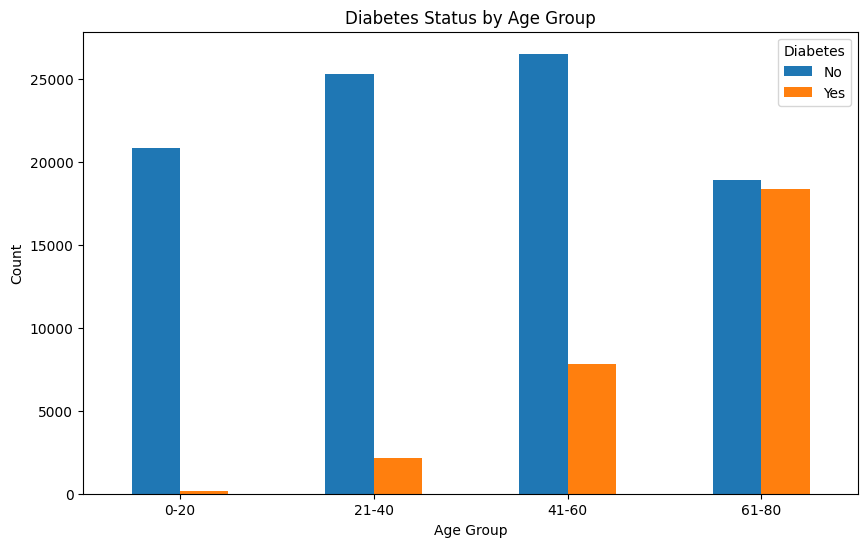

In [4]:
df['age'] = pd.cut(df['age'], bins=[0, 20, 40, 60, 80], labels=['0-20', '21-40', '41-60', '61-80'])
age_diabetes_ct = pd.crosstab(df['age'], df['diabetes'])
age_diabetes_ct.plot(kind='bar', figsize=(10, 6))
plt.title('Diabetes Status by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Count')
plt.legend(title='Diabetes', labels=['No', 'Yes'])
plt.xticks(rotation=0)
plt.show()

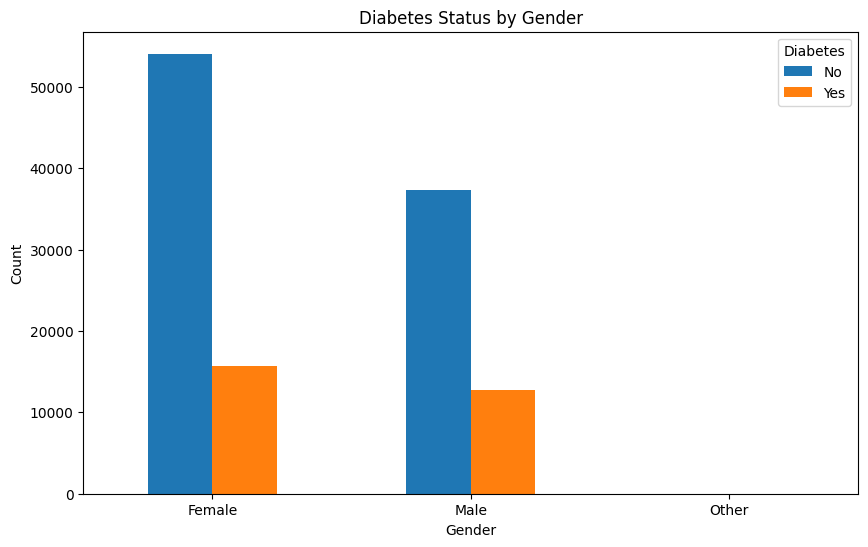

In [5]:
# Create a cross-tabulation table
gender_diabetes_ct = pd.crosstab(df['gender'], df['diabetes'])

# Plot the table as a grouped bar chart
gender_diabetes_ct.plot(kind='bar', figsize=(10, 6))

plt.title('Diabetes Status by Gender')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.legend(title='Diabetes', labels=['No', 'Yes'])
plt.xticks(rotation=0)
plt.show()

In [8]:
pipe = build_svm_pipeline()

param_grid = {
        'classifier__C': [0.1, 1, 10],
        'classifier__kernel': ['linear']
    }
X, y = preprocessing(df)
run_experiment(X, y, pipe, param_grid)

Model saved as: svm_linear_model.pkl
Best Parameters: {'classifier__C': 0.1, 'classifier__kernel': 'linear'}
   mean_test_accuracy  mean_test_f1  mean_test_precision  mean_test_recall  \
0            0.851375      0.738471             0.642183          0.868725   
1            0.851375      0.738471             0.642183          0.868725   
2            0.851375      0.738471             0.642183          0.868725   

   param_classifier__C param_classifier__kernel  
0                  0.1                   linear  
1                  1.0                   linear  
2                 10.0                   linear  


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scaler', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",0.1
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'linear'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'


In [9]:
pipe = build_svm_pipeline()

param_grid = {
    'classifier__C': [0.1, 1, 10],
    'classifier__degree': [1, 2, 3],
    'classifier__kernel': ['poly']
}
X, y = preprocessing(df)
run_experiment(X, y, pipe, param_grid)

Model saved as: svm_poly_model.pkl
Best Parameters: {'classifier__C': 0.1, 'classifier__degree': 3, 'classifier__kernel': 'poly'}
   mean_test_accuracy  mean_test_f1  mean_test_precision  mean_test_recall  \
2            0.867542      0.757717             0.678727          0.857513   
5            0.863167      0.755327             0.664787          0.874418   
8            0.862750      0.755057             0.663573          0.875798   
6            0.851375      0.738471             0.642183          0.868725   
0            0.851333      0.738455             0.642065          0.868898   
3            0.851292      0.738362             0.642019          0.868725   
7            0.811000      0.629593             0.597767          0.664999   
4            0.811500      0.628632             0.599687          0.660514   
1            0.811417      0.618767             0.604609          0.633604   

   param_classifier__C  param_classifier__degree param_classifier__kernel  
2            

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scaler', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",0.1
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'poly'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'


In [5]:
pipe = build_svm_pipeline()

param_grid = {
    'classifier__C': [0.1, 1, 10],
    'classifier__gamma': [0.01, 0.1, 1],
    'classifier__kernel': ['rbf']
}
X, y = preprocessing(df)
run_experiment(X, y, pipe, param_grid)

Model saved as: svm_rbf_model.pkl
Best Parameters: {'classifier__C': 10, 'classifier__gamma': 1, 'classifier__kernel': 'rbf'}
   mean_test_accuracy  mean_test_f1  mean_test_precision  mean_test_recall  \
8            0.880042      0.780145             0.699918          0.881145   
5            0.878125      0.780026             0.691467          0.894601   
7            0.872625      0.773371             0.678107          0.899776   
2            0.865583      0.764043             0.663238          0.900983   
4            0.862000      0.758987             0.656388          0.899603   
1            0.860042      0.753865             0.655287          0.887356   
3            0.856250      0.745538             0.651205          0.871830   
6            0.853750      0.745468             0.643063          0.886666   
0            0.852833      0.740409             0.645025          0.868898   

   param_classifier__C  param_classifier__gamma param_classifier__kernel  
8                 

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scaler', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",10
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",1


In [6]:
def build_final_svm_model(X, y):
    """
    Trains a single SVM model on an 80/20 split using specific parameters.
    """
    # 1. Split the data 80% Train / 20% Test
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

 
    model_pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('classifier', svm.SVC(class_weight='balanced', C=10, kernel='rbf', gamma=1))
    ])

    model_pipeline.fit(X_train, y_train)

    # 4. Evaluate on the 20% test set
    y_pred = model_pipeline.predict(X_test)
    report_dict = classification_report(y_test, y_pred, output_dict=True)

    # 3. Convert to a DataFrame for a clean, non-manual view
    # We transpose (.T) so metrics are columns and classes are rows
    metrics_df = pd.DataFrame(report_dict).transpose()

    print("\n--- Model Performance Metrics ---")
    # This displays Accuracy, Precision, Recall, and F1 for each class
    print(metrics_df.round(4)) 

    # 5. Save the model
    filename = f"final_svm_rbf_model.joblib"
    joblib.dump(model_pipeline, filename)

    return model_pipeline

build_final_svm_model(X,y)



--- Model Performance Metrics ---
              precision  recall  f1-score   support
0                0.9587  0.8797    0.9175  18203.00
1                0.6999  0.8811    0.7801   5797.00
accuracy         0.8800  0.8800    0.8800      0.88
macro avg        0.8293  0.8804    0.8488  24000.00
weighted avg     0.8962  0.8800    0.8843  24000.00


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scaler', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",10
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",1


In [5]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model_path = 'svm_rbf_model.pkl'
loaded_model = joblib.load(model_path)
print(f"Model loaded successfully from {model_path}")

# 2. Use the model to predict
# Ensure X_test and y_test are the variables from your 80/20 split
y_pred = loaded_model.predict(X_test)

# 3. Get Accuracy, Precision, Recall, and F1 automatically
# Setting output_dict=True turns the report into a clean table
report = classification_report(y_test, y_pred, output_dict=True)
metrics_df = pd.DataFrame(report).transpose()

# 4. Display the results
print("\n--- Final Test Results ---")
# This will show class 0, class 1, and the overall accuracy/averages
print(metrics_df[['precision', 'recall', 'f1-score', 'support']].round(4))

# Explicitly print the Accuracy
accuracy = report['accuracy']
print(f"\nOverall Accuracy: {accuracy:.4f}")

Model loaded successfully from svm_rbf_model.pkl

--- Final Test Results ---
              precision  recall  f1-score     support
0                0.9737  0.8917    0.9309  18203.0000
1                0.7311  0.9244    0.8165   5797.0000
accuracy         0.8996  0.8996    0.8996      0.8996
macro avg        0.8524  0.9081    0.8737  24000.0000
weighted avg     0.9151  0.8996    0.9033  24000.0000

Overall Accuracy: 0.8996
